<a href="https://colab.research.google.com/github/Sarah1542/Smart-Adaptive-Environment-Monitoring-Decision-System/blob/RBF/RBF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Datasets & Cleaning

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD DATASETS
# ==========================================
pca_df = pd.read_csv('pca_output.csv')
som_df = pd.read_csv('som_results.csv')

# ==========================================
# 2. DATA MERGING & MAPPING
# ==========================================
data = pca_df.copy()

state_mapping = {
    'Normal': 0,
    'Warning': 1,
    'Dangerous': 2
}

data['target'] = som_df['State'].map(state_mapping)

# ==========================================
# 3. DATA CLEANING
# ==========================================
data_clean = data.dropna().copy()

# ==========================================
# 4. FINAL DATA PREPARATION
# ==========================================
X = data_clean[['PC1', 'PC2']].values
y = data_clean['target'].values.astype(int)

n_classes = len(np.unique(y))

# ==========================================
# 5. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# 6. DATA SUMMARY
# ==========================================
print("Data Preparation Completed Successfully!")
print(f"Total clean samples: {len(data_clean)}")
print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Classes found: {np.unique(y)}")

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFirst 5 rows of prepared data:")
print(data_clean.head())

Data Preparation Completed Successfully!
Total clean samples: 765
Feature shape: (765, 2)
Target shape: (765,)
Classes found: [0 1 2]

Training samples: 612
Testing samples: 153

First 5 rows of prepared data:
        PC1       PC2  target
0 -0.167565 -2.242712     0.0
1 -0.239892 -1.184357     0.0
2 -0.143372 -0.263326     1.0
4 -0.372828 -0.046831     2.0
5 -0.222956 -1.135257     0.0


#RBF Model & GA

In [ ]:
import numpy as np
import random
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
random.seed(42)

# ==========================================
# RBF NETWORK
# ==========================================
class RBFNetwork:
    def __init__(self, n_input=2, n_hidden=30, n_output=3):
        self.n_input = n_input
        self.n_output = n_output

        self.fixed_hidden = n_hidden
        self.centers = None
        self.sigmas = None
        self.weights = np.random.randn(n_hidden, n_output) * 0.1

    # ==========================================
    # FIXED CENTERS
    # ==========================================
    def init_centers_kmeans(self, X, y):
        centers = []
        classes = np.unique(y)

        per_class = max(3, self.fixed_hidden // len(classes))

        for c in classes:
            X_c = X[y == c]

            kmeans = KMeans(
                n_clusters=min(per_class, len(X_c)),
                random_state=42,
                n_init=10
            )
            kmeans.fit(X_c)
            centers.append(kmeans.cluster_centers_)

        self.centers = np.vstack(centers)


        self.centers = self.centers[:self.fixed_hidden]

        # ==========================================
        # sigma
        # ==========================================
        dists = []
        for i in range(len(self.centers)):
            for j in range(i + 1, len(self.centers)):
                dists.append(np.linalg.norm(self.centers[i] - self.centers[j]))

        sigma = np.percentile(dists, 25) if len(dists) > 0 else 1.0
        self.sigmas = np.ones(self.fixed_hidden) * sigma

    # ==========================================
    def _gaussian(self, x, c, s):
        s = max(s, 1e-6)
        return np.exp(-np.linalg.norm(x - c) ** 2 / (2 * s ** 2))

    def _softmax(self, x):
        x = x - np.max(x)
        e = np.exp(x)
        return e / (np.sum(e) + 1e-8)

    def predict(self, X):
        outs = []

        for x in X:
            phi = np.array([
                self._gaussian(x, c, s)
                for c, s in zip(self.centers, self.sigmas)
            ])

            phi = phi / (np.sum(phi) + 1e-8)
            out = np.dot(phi, self.weights)
            outs.append(self._softmax(out))

        return np.array(outs)

    def predict_classes(self, X):
        return np.argmax(self.predict(X), axis=1)

    # ==========================================
    #  FIXED FITNESS
    # ==========================================
    def fitness(self, X, y):
        pred = self.predict_classes(X)

        macro = f1_score(y, pred, average='macro')

        recalls = []
        penalty = 0

        for c in np.unique(y):
            r = np.sum((pred == c) & (y == c)) / (np.sum(y == c) + 1e-8)
            recalls.append(r)

            if r < 0.4:
                penalty -= 0.7

        balance = 1 - np.std(recalls)

        return macro + 0.5 * balance + penalty


# ==========================================
# GA
# ==========================================
class GA_RBF:
    def __init__(self, pop_size=30, mutation_rate=0.06):
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate

    def initialize_population(self):
        return [RBFNetwork() for _ in range(self.pop_size)]

    def evolve(self, X_train, y_train, X_val, y_val, generations=30):

        pop = self.initialize_population()

        for m in pop:
            m.init_centers_kmeans(X_train, y_train)

        best = None
        best_score = -1

        top_k = max(5, self.pop_size // 3)

        for gen in range(generations):

            scores = [m.fitness(X_val, y_val) for m in pop]
            idx = np.argsort(scores)[::-1]
            pop = [pop[i] for i in idx]

            if scores[idx[0]] > best_score:
                best_score = scores[idx[0]]
                best = pop[0]

            print(f"Gen {gen+1} | Best Score: {best_score:.4f}")

            new_pop = pop[:4]

            while len(new_pop) < self.pop_size:

                p1, p2 = random.sample(pop[:top_k], 2)

                g1 = np.concatenate([
                    p1.centers.flatten(),
                    p1.sigmas.flatten(),
                    p1.weights.flatten()
                ])

                g2 = np.concatenate([
                    p2.centers.flatten(),
                    p2.sigmas.flatten(),
                    p2.weights.flatten()
                ])

                cut = random.randint(1, len(g1) - 2)
                child_g = np.concatenate([g1[:cut], g2[cut:]])

                if random.random() < self.mutation_rate:
                    child_g += np.random.normal(0, 0.02, child_g.shape)

                child = RBFNetwork()

                c = child.fixed_hidden * child.n_input
                s = child.fixed_hidden

                child.centers = child_g[:c].reshape(child.fixed_hidden, child.n_input)
                child.sigmas = child_g[c:c+s]
                child.weights = child_g[c+s:].reshape(child.fixed_hidden, child.n_output)

                new_pop.append(child)

            pop = new_pop

        return best


# ==========================================
# DATA
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train_g, X_val, y_train_g, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# ==========================================
# RUN
# ==========================================
ga = GA_RBF(pop_size=30, mutation_rate=0.06)

best_model = ga.evolve(X_train_g, y_train_g, X_val, y_val, generations=30)

# ==========================================
# TEST
# ==========================================
pred = best_model.predict_classes(X_test)

print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, zero_division=0))

Gen 1 | Best Score: 1.1078
Gen 2 | Best Score: 1.1078
Gen 3 | Best Score: 1.2076
Gen 4 | Best Score: 1.2076
Gen 5 | Best Score: 1.2842
Gen 6 | Best Score: 1.2842
Gen 7 | Best Score: 1.2842
Gen 8 | Best Score: 1.2901
Gen 9 | Best Score: 1.2901
Gen 10 | Best Score: 1.3465
Gen 11 | Best Score: 1.3465
Gen 12 | Best Score: 1.3508
Gen 13 | Best Score: 1.3992
Gen 14 | Best Score: 1.3992
Gen 15 | Best Score: 1.4346
Gen 16 | Best Score: 1.4346
Gen 17 | Best Score: 1.4406
Gen 18 | Best Score: 1.4545
Gen 19 | Best Score: 1.4545
Gen 20 | Best Score: 1.4545
Gen 21 | Best Score: 1.4545
Gen 22 | Best Score: 1.4545
Gen 23 | Best Score: 1.4545
Gen 24 | Best Score: 1.4545
Gen 25 | Best Score: 1.4545
Gen 26 | Best Score: 1.4545
Gen 27 | Best Score: 1.4545
Gen 28 | Best Score: 1.4545
Gen 29 | Best Score: 1.4545
Gen 30 | Best Score: 1.4545

Accuracy: 0.9411764705882353

Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93        37
           1       0

#Data Exploration

In [ ]:
# ==========================================
# DATA INSPECTION (First 5 Samples)
# ==========================================

print("Input Features - X (PC1 and PC2):")
print(X[:5])

print("\n" + "="*40 + "\n")

print("Target Labels - y (Mapped from SOM):")
print(y[:5])

print("\n" + "="*40 + "\n")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique Classes: {np.unique(y)}")

print("\n" + "="*40 + "\n")

# ==========================================
# TRAIN / TEST DATA INSPECTION
# ==========================================

print("Training Features Sample:")
print(X_train[:5])

print("\nTraining Labels Sample:")
print(y_train[:5])

print("\n" + "="*40 + "\n")

print("Testing Features Sample:")
print(X_test[:5])

print("\nTesting Labels Sample:")
print(y_test[:5])

print("\n" + "="*40 + "\n")

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

print(f"Training Classes Distribution: {np.bincount(y_train)}")
print(f"Testing Classes Distribution: {np.bincount(y_test)}")

Input Features - X (PC1 and PC2):
[[-0.16756459 -2.2427116 ]
 [-0.2398916  -1.18435654]
 [-0.14337191 -0.26332619]
 [-0.37282773 -0.046831  ]
 [-0.22295633 -1.13525721]]


Target Labels - y (Mapped from SOM):
[0 0 1 2 0]


X shape: (765, 2)
y shape: (765,)
Unique Classes: [0 1 2]


Training Features Sample:
[[-0.09115894  0.64008656]
 [-0.02843158  0.95779462]
 [-0.0454986   0.94767615]
 [-0.19506134  0.48912535]
 [-0.14626155 -0.45753881]]

Training Labels Sample:
[2 2 2 2 1]


Testing Features Sample:
[[-1.66069228e-01 -1.39803368e+00]
 [-2.57635150e-01 -8.05613678e-01]
 [-8.26895790e-02  1.23227704e+00]
 [-1.00026672e-03  4.88078192e-01]
 [ 7.68032204e-02 -1.67093725e+00]]

Testing Labels Sample:
[0 0 2 2 0]


Training Shape: (612, 2)
Testing Shape: (153, 2)
Training Classes Distribution: [147 211 254]
Testing Classes Distribution: [37 53 63]


#Save CSV file

In [ ]:
# ==========================================
# 5. SAVE RBF PREDICTIONS TO CSV
# ==========================================

import pandas as pd
import numpy as np

# Make predictions
final_predictions = best_model.predict(X)

# Convert raw outputs to class labels
pred_classes = np.argmax(final_predictions, axis=1)

# Create results dataframe
results_df = pd.DataFrame(X, columns=['PC1', 'PC2'])

# Add predictions (class-based)
results_df['Predicted_State'] = pred_classes

# Add actual labels
results_df['Actual_State'] = y

# Save to CSV
results_df.to_csv('rbf_final_results.csv', index=False)

print("Final results saved successfully to 'rbf_final_results.csv'!")

Final results saved successfully to 'rbf_final_results.csv'!


#RBF Visualization

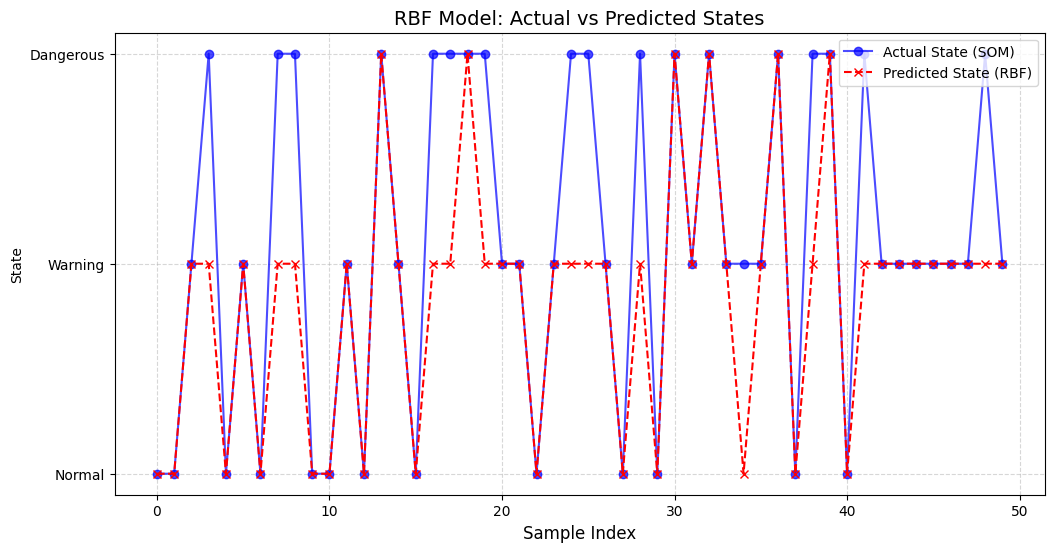

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# VISUALIZATION
# ==========================================

start = 0
end = 50

actual = y[start:end]

pred_classes = np.argmax(final_predictions, axis=1)[start:end]

sample_range = np.arange(len(actual))

plt.figure(figsize=(12, 6))

# Actual
plt.plot(sample_range, actual, 'bo-', label='Actual State (SOM)', markersize=6, alpha=0.7)

# Predicted
plt.plot(sample_range, pred_classes, 'rx--', label='Predicted State (RBF)', markersize=6)

# Formatting
plt.title('RBF Model: Actual vs Predicted States', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('State')

plt.yticks([0, 1, 2], ['Normal', 'Warning', 'Dangerous'])

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#Confusion Matrix

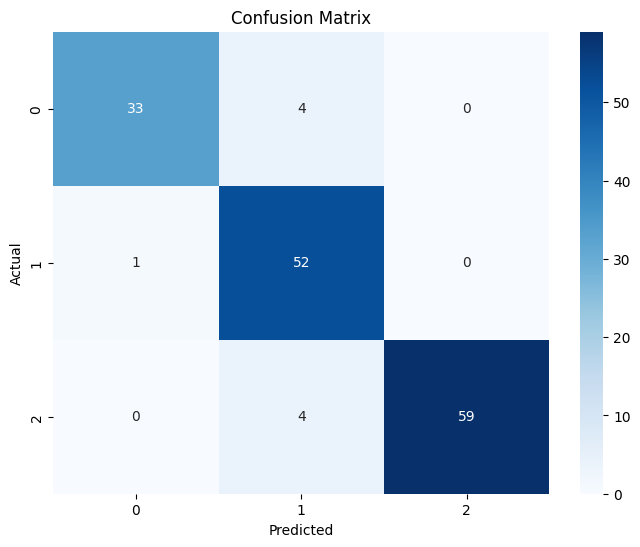

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Model Saving

In [ ]:
import joblib

model_bundle = {
    "model": best_model,
    "scaler": scaler
}

joblib.dump(model_bundle, "rbf_ga_bundle.pkl")

['rbf_ga_bundle.pkl']